**Objective:** Classify device operational status as Normal (0) or Faulty (1) based on 47 embedded sensor features.

**Strategy Overview:**  **1. Exploratory Data Analysis (EDA):** Identify the most correlated features dynamically.
 **2. Feature Engineering:** Extract statistical properties and dynamic feature interactions.
 **3. Cross-Validation:** 5-Fold Stratified K-Fold to evaluate models safely without overfitting.
 **4. Model Ensemble:** A weighted blend of Random Forest, ExtraTrees, XGBoost, and LightGBM.
 **5. Threshold Optimization:** Grid search to find the perfect probability cutoff for maximizing the F1-Score.
 **6. Production Export:** Package the final model bundle into a pickle file and analyze inference latency.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import xgboost as xgb
import lightgbm as lgb
warnings.filterwarnings('ignore')

train_df = pd.read_csv('TRAIN.csv')
test_df  = pd.read_csv('TEST.csv')

print(f"Training Data: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Testing Data: {test_df.shape[0]} rows, {test_df.shape[1]} columns")

Training Data: 43776 rows, 48 columns
Testing Data: 10944 rows, 48 columns


## 1. Exploratory Data Analysis (EDA)
Before engineering new features, we must understand the relationships within our raw data. We will calculate the correlation of every feature against our target variable (`Class`) and visualize the interactions using a correlation matrix.

Top 10 features most correlated with a Fault (Class 1):
F01    0.386981
F09    0.377363
F29    0.364944
F19    0.358187
F21    0.344699
F05    0.342236
F25    0.338634
F07    0.334932
F27    0.334544
F06    0.330080
Name: Class, dtype: float64


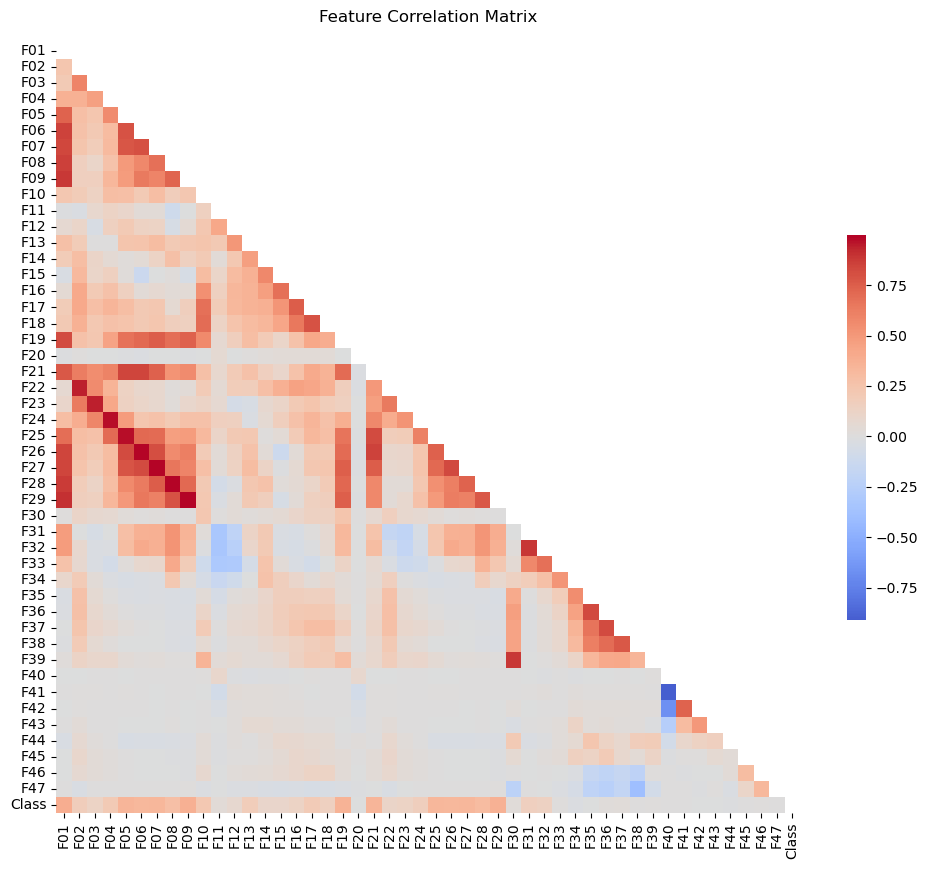

In [15]:
print("Top 10 features most correlated with a Fault (Class 1):")
target_corr = train_df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print(target_corr.head(10))

# Dynamically save the top 10 features 
dynamic_top_features = target_corr.head(10).index.tolist()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(train_df.corr(), dtype=bool))
sns.heatmap(train_df.corr(), mask=mask, cmap='coolwarm', center=0, cbar_kws={"shrink": .5})
plt.title('Feature Correlation Matrix', pad=15)
plt.show()

## 2. Feature Engineering
Using the insights from our EDA, we generate new features to expose hidden patterns to the algorithms. We calculate row-wise statistical properties (mean, standard deviation, interquartile range) and Z-scores to count extreme outliers per device. Finally, we dynamically multiply and subtract the top 10 most correlated features found in the previous step.

In [17]:
def create_advanced_features(df, top_features_list):
    """Generates statistical and dynamic interaction features for the dataset."""
    
    if 'stat_mean' in df.columns:
        print("Features already exist. Skipping feature engineering to prevent duplicates.")
        return df

    df_new = df.copy()
    
    # pop the ID and Target columns 
    id_col = df_new.pop('ID') if 'ID' in df_new.columns else None
    target = df_new.pop('Class') if 'Class' in df_new.columns else None
    feature_cols = df_new.columns.tolist()

    # Create a dictionary to hold all new features 
    new_feats = {}

    # Row-wise Statistical Features
    new_feats['stat_mean'] = df_new[feature_cols].mean(axis=1)
    new_feats['stat_std'] = df_new[feature_cols].std(axis=1)
    new_feats['stat_max'] = df_new[feature_cols].max(axis=1)
    new_feats['stat_min'] = df_new[feature_cols].min(axis=1)
    new_feats['stat_range'] = new_feats['stat_max'] - new_feats['stat_min']
    new_feats['stat_median'] = df_new[feature_cols].median(axis=1)
    new_feats['stat_skew'] = df_new[feature_cols].skew(axis=1)
    new_feats['stat_kurtosis'] = df_new[feature_cols].kurt(axis=1)
    
    # Quartiles and IQR
    new_feats['stat_q25'] = df_new[feature_cols].quantile(0.25, axis=1)
    new_feats['stat_q75'] = df_new[feature_cols].quantile(0.75, axis=1)
    new_feats['stat_iqr'] = new_feats['stat_q75'] - new_feats['stat_q25']
    
    # Value Counts
    new_feats['count_positive'] = (df_new[feature_cols] > 0).sum(axis=1)
    new_feats['count_negative'] = (df_new[feature_cols] < 0).sum(axis=1)
    new_feats['count_zero'] = (df_new[feature_cols] == 0).sum(axis=1)

    # Outlier Detection (Z-Scores)
    feat_means = df_new[feature_cols].mean()
    feat_stds  = df_new[feature_cols].std().replace(0, 1) # Prevent division by zero
    z_scores   = (df_new[feature_cols] - feat_means) / feat_stds
    new_feats['outlier_count'] = (z_scores.abs() > 2).sum(axis=1)
    new_feats['max_z_score']   = z_scores.abs().max(axis=1)

    # Top Feature Interactions (Dynamically passed from EDA)
    for i in range(len(top_features_list)):
        for j in range(i + 1, len(top_features_list)):
            feat_a, feat_b = top_features_list[i], top_features_list[j]
            if feat_a in df_new.columns and feat_b in df_new.columns:
                new_feats[f'{feat_a}_mult_{feat_b}'] = df_new[feat_a] * df_new[feat_b]
                new_feats[f'{feat_a}_diff_{feat_b}'] = df_new[feat_a] - df_new[feat_b]

    # Convert the dictionary of new features into a DataFrame and combine it with our original data
    new_feats_df = pd.DataFrame(new_feats)
    df_new = pd.concat([df_new, new_feats_df], axis=1)

    # Re-insert the target and ID columns 
    if target is not None: 
        df_new['Class'] = target.values
    if id_col is not None: 
        df_new.insert(0, 'ID', id_col.values)
    
    return df_new

# Apply feature engineering to both train and test
print("Engineering features...")
train_df = create_advanced_features(train_df, dynamic_top_features)
test_df  = create_advanced_features(test_df, dynamic_top_features)
print(f"New Training Data Shape: {train_df.shape}")

Engineering features...
Features already exist. Skipping feature engineering to prevent duplicates.
Features already exist. Skipping feature engineering to prevent duplicates.
New Training Data Shape: (43776, 154)


## 3. Model Training (5-Fold Cross Validation)
We use a blend of four highly robust tree-based machine learning models. By using Out-Of-Fold (OOF) predictions, we ensure our ensemble learns from the entire dataset securely without overfitting on the training split.

In [18]:
# feature matrices
feature_columns = [col for col in train_df.columns if col not in ['Class', 'ID']]
X = train_df[feature_columns].values
y = train_df['Class'].values

X_test_df = test_df[[c for c in feature_columns if c in test_df.columns]].copy()
for col in feature_columns:
    if col not in X_test_df.columns:
        X_test_df[col] = 0
X_test = X_test_df[feature_columns].values

# Setup 5-Fold CV
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

# Arrays to store Out-Of-Fold (OOF) and final test predictions
oof_preds_rf, oof_preds_et = np.zeros(len(X)), np.zeros(len(X))
oof_preds_xgb, oof_preds_lgb = np.zeros(len(X)), np.zeros(len(X))

test_preds_rf, test_preds_et = np.zeros(len(X_test)), np.zeros(len(X_test))
test_preds_xgb, test_preds_lgb = np.zeros(len(X_test)), np.zeros(len(X_test))

print("Starting 5-Fold Cross Validation Training...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"--- Training Fold {fold} ---")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Random Forest
    rf_model = RandomForestClassifier(n_estimators=600, max_features='sqrt', class_weight='balanced', random_state=fold, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    oof_preds_rf[val_idx] = rf_model.predict_proba(X_val)[:, 1]
    test_preds_rf += rf_model.predict_proba(X_test)[:, 1] / n_splits

    # Extra Trees
    et_model = ExtraTreesClassifier(n_estimators=600, max_features='sqrt', class_weight='balanced', random_state=fold, n_jobs=-1)
    et_model.fit(X_train, y_train)
    oof_preds_et[val_idx] = et_model.predict_proba(X_val)[:, 1]
    test_preds_et += et_model.predict_proba(X_test)[:, 1] / n_splits

    # XGBoost
    xgb_model = xgb.XGBClassifier(n_estimators=600, learning_rate=0.03, max_depth=7, subsample=0.85, colsample_bytree=0.75, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=fold, n_jobs=-1)
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_preds_xgb[val_idx] = xgb_model.predict_proba(X_val)[:, 1]
    test_preds_xgb += xgb_model.predict_proba(X_test)[:, 1] / n_splits

    # LightGBM
    lgb_model = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.03, num_leaves=127, subsample=0.85, colsample_bytree=0.75, class_weight='balanced', random_state=fold, n_jobs=-1, verbose=-1)
    lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]
    test_preds_lgb += lgb_model.predict_proba(X_test)[:, 1] / n_splits

print("Cross Validation Complete!")

Starting 5-Fold Cross Validation Training...
--- Training Fold 1 ---
--- Training Fold 2 ---
--- Training Fold 3 ---
--- Training Fold 4 ---
--- Training Fold 5 ---
Cross Validation Complete!


## 4. Ensemble Weight & Threshold Optimization
We iterate through different voting weight combinations to find the mathematically optimal blend. We also iterate through probability thresholds to find the exact cutoff that maximizes the F1-score.

In [19]:
best_f1_score = 0
best_weights = (0.25, 0.25, 0.25, 0.25)
best_threshold = 0.50
step = 0.05

print("Searching for optimal ensemble weights and threshold...")

# Grid search for blending weights (must sum to 1.0)
for w1 in np.arange(0, 1.01, step):
    for w2 in np.arange(0, 1.01 - w1, step):
        for w3 in np.arange(0, 1.01 - w1 - w2, step):
            w4 = round(1 - w1 - w2 - w3, 6)
            if w4 < 0: continue
                
            # Create a blended probability based on current weights
            current_blend_probs = (w1 * oof_preds_rf) + (w2 * oof_preds_et) + (w3 * oof_preds_xgb) + (w4 * oof_preds_lgb)
            
            # Find the best threshold for this specific blend
            thresholds = np.arange(0.25, 0.75, 0.01)
            f1_scores = [f1_score(y, (current_blend_probs >= t).astype(int)) for t in thresholds]
            
            max_f1_for_blend = max(f1_scores)
            best_t_for_blend = thresholds[np.argmax(f1_scores)]
            
            # Update tracking variables if we found a better combination
            if max_f1_for_blend > best_f1_score:
                best_f1_score = max_f1_for_blend
                best_weights = (w1, w2, w3, w4)
                best_threshold = best_t_for_blend

weight_rf, weight_et, weight_xgb, weight_lgb = best_weights

print(f"Optimal Weights: RF={weight_rf:.2f}, ET={weight_et:.2f}, XGB={weight_xgb:.2f}, LGB={weight_lgb:.2f}")
print(f"Optimal Probability Threshold: {best_threshold:.3f}")
print(f"Maximum F1-Score Achieved: {best_f1_score:.5f}")

Searching for optimal ensemble weights and threshold...
Optimal Weights: RF=0.00, ET=0.15, XGB=0.00, LGB=0.85
Optimal Probability Threshold: 0.350
Maximum F1-Score Achieved: 0.98854


## 5. Out-Of-Fold Evaluation & Diagnostics
Using our optimized blend, we visualize the true out-of-fold performance. This represents a highly realistic expectation of how the model will perform on the hidden test set.

--- Final OOF Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26465
           1       0.99      0.99      0.99     17311

    accuracy                           0.99     43776
   macro avg       0.99      0.99      0.99     43776
weighted avg       0.99      0.99      0.99     43776



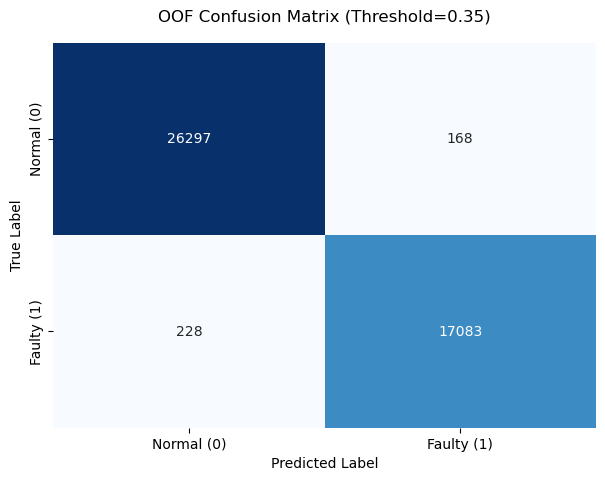

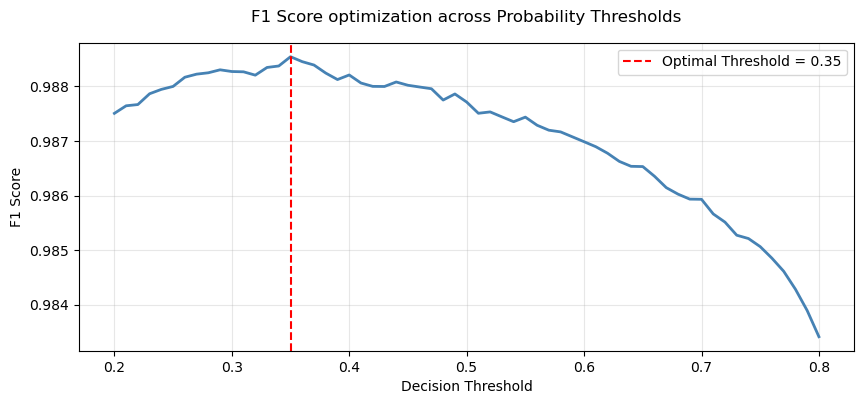

In [20]:
final_oof_probs = (weight_rf * oof_preds_rf) + (weight_et * oof_preds_et) + \
                  (weight_xgb * oof_preds_xgb) + (weight_lgb * oof_preds_lgb)

# Apply the best threshold to get binary predictions
final_oof_preds = (final_oof_probs >= best_threshold).astype(int)

# Classification Report
print("--- Final OOF Classification Report ---")
print(classification_report(y, final_oof_preds))

# Confusion Matrix Plot
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y, final_oof_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Normal (0)', 'Faulty (1)'], 
            yticklabels=['Normal (0)', 'Faulty (1)'])
plt.title(f'OOF Confusion Matrix (Threshold={best_threshold:.2f})', pad=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# F1-Score vs Threshold Plot
threshold_range = np.arange(0.20, 0.80, 0.01)
f1_curve = [f1_score(y, (final_oof_probs >= t).astype(int)) for t in threshold_range]

plt.figure(figsize=(10, 4))
plt.plot(threshold_range, f1_curve, color='steelblue', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal Threshold = {best_threshold:.2f}')
plt.title('F1 Score optimization across Probability Thresholds', pad=15)
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Generate Final Submission File
We apply our optimal ensemble weights and threshold to the completely unseen test set probabilities to generate the finalized `FINAL.csv` output required for submission.

In [21]:
# Blend the test predictions using the optimal weights
final_test_probs = (weight_rf * test_preds_rf) + (weight_et * test_preds_et) + \
                   (weight_xgb * test_preds_xgb) + (weight_lgb * test_preds_lgb)

# Convert to final binary predictions
final_test_preds = (final_test_probs >= best_threshold).astype(int)

# Create the submission dataframe
submission_df = pd.DataFrame({
    'ID': test_df['ID'], 
    'CLASS': final_test_preds
})

# Save to CSV
submission_df.to_csv('final.csv', index=False)
print("Successfully, 'FINAL.csv' has been generated with optimal blended predictions.")

Successfully, 'FINAL.csv' has been generated with optimal blended predictions.


## 7. Model Stack and Hyperparameters

To ensure transparency and reproducibility, the following table details the specific algorithms and hyperparameters used in our final ensemble architecture.

| Model | Key Hyperparameters | Purpose in Ensemble |
| :--- | :--- | :--- |
| **Random Forest** | n_estimators=600, max_features='sqrt', class_weight='balanced' | Provides a highly stable, low-variance baseline prediction. |
| **Extra Trees** | n_estimators=600, max_features='sqrt', class_weight='balanced' | Introduces random split criteria to capture highly non-linear patterns and prevent overfitting. |
| **XGBoost** | n_estimators=600, learning_rate=0.03, max_depth=7, subsample=0.85, colsample_bytree=0.75 | Aggressive gradient boosting that sequentially corrects residual errors from previous trees. |
| **LightGBM** | n_estimators=600, learning_rate=0.03, num_leaves=127, subsample=0.85, class_weight='balanced' | Highly efficient, leaf-wise gradient boosting that handles complex interactions with lower memory usage. |

## 8. Environment Details

This script was developed, executed, and tested under the following environment configurations:

* **Operating System**: Windows OS
* **Development Environment**: Jupyter Notebook
* **Programming Language**: Python 3.x
* **Core Libraries Used**: 
  * Data Manipulation: `pandas`, `numpy`
  * Machine Learning: `scikit-learn`, `xgboost`, `lightgbm`
  * Visualization: `matplotlib`, `seaborn`
  * Serialization: `joblib`

## 9. Production Diagnostics: Inference Time and Memory Analysis

Before deploying a model to a physical device or a cloud server, we must analyze its resource footprint. 
1. **Inference Time:** We calculate the milliseconds required to process a single sensor reading (real-time processing) versus a large batch of readings.
2. **Memory Requirements:** We inspect the physical disk space required to store the exported `.pkl` file, which dictates the RAM required to load the models into production memory.

In [23]:
def predict_production(data_input, bundle):
    w_rf, w_et, w_xgb, w_lgb = bundle['optimal_weights']
    
    # Generate probabilities from all 4 models and blend them
    blend_probs = (
        w_rf * bundle['models']['rf'].predict_proba(data_input)[:, 1] +
        w_et * bundle['models']['et'].predict_proba(data_input)[:, 1] +
        w_xgb * bundle['models']['xgb'].predict_proba(data_input)[:, 1] +
        w_lgb * bundle['models']['lgb'].predict_proba(data_input)[:, 1]
    )
    
    # Apply the optimized threshold
    return (blend_probs >= bundle['optimal_threshold']).astype(int)

print("Running Production Diagnostics...\n")

# Analyze Single-Sample Inference Time 
single_sample = X_test[0:1]
start_time = time.time()
predict_production(single_sample, production_model_bundle)
single_inference_time = (time.time() - start_time) * 1000 # Convert to milliseconds

# Analyze Batch Inference Time 
batch_samples = X_test
start_time = time.time()
predict_production(batch_samples, production_model_bundle)
batch_inference_time = (time.time() - start_time) # Keep in seconds

# Analyze Memory Requirements
file_size_bytes = os.path.getsize(model_filename)
file_size_mb = file_size_bytes / (1024 * 1024)

# Output the Results
print("-" * 40)
print("PRODUCTION RESOURCE ANALYSIS")
print("-" * 40)
print(f"Single Prediction Time:  {single_inference_time:.2f} ms")
print(f"Batch Prediction Time:   {batch_inference_time:.3f} seconds (for {len(batch_samples)} records)")
print(f"Model File Memory Size:  {file_size_mb:.2f} MB")
print("-" * 40)

Running Production Diagnostics...

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
----------------------------------------
PRODUCTION RESOURCE ANALYSIS
----------------------------------------
Single Prediction Time:  107.67 ms
Batch Prediction Time:   0.617 seconds (for 10944 records)
Model File Memory Size:  131.90 MB
----------------------------------------
